<a href="https://colab.research.google.com/github/Swathi04705/Applied-Machine-Learning-Lab/blob/main/biasvariance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

#generate reproducible nonlinear data
np.random.seed(42)

X = np.linspace(0,10,40).reshape(-1,1)#40 no. from 1 to 10 and in 2D(reshape)


#np.random.normal(0,5,40) is to generate random noise
#and add realistic variation to the output data
#np.random.normal(mean,standard_deviation, number_of_variables)
y = 2 + 0.5 * X[:,0] ** 2 + np.random.normal(0, 5, 40)


#Divide the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


degrees = [1,2,10]


#include_bias = False -is to tell PolynomialFeatures not to create
#an additional constant column containing only 1s.
for degree in degrees:
  model = make_pipeline(
      PolynomialFeatures(degree=degree, include_bias=False),
      LinearRegression()
  )
  model.fit(X_train, y_train)

  train_prediction = model.predict(X_train)
  test_prediction = model.predict(X_test)

  train_mse = mean_squared_error(y_train, train_prediction)
  test_mse = mean_squared_error(y_test, test_prediction)

  print(f"Degree :{degree}")
  print(f"Train MSE: {train_mse:.2f}")
  print(f"Test MSE: {test_mse:.2f}")
  print()

Degree :1
Train MSE: 42.90
Test MSE: 42.99

Degree :2
Train MSE: 20.44
Test MSE: 19.79

Degree :10
Train MSE: 12.89
Test MSE: 95.21



1-> underfitting (High bias and low variance)-simple model

2-> train and test error are similar but train greater than test-good model

3-> overfitting(test error is higher than traing error) -complex model

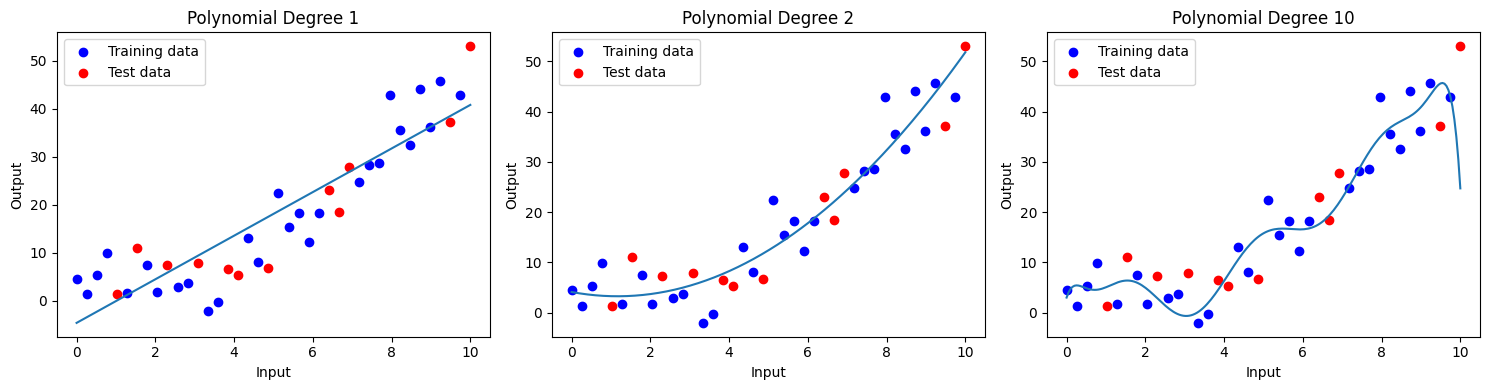

In [ ]:
#to plot
X_plot = np.linspace(0, 10, 200).reshape(-1,1)

plt.figure (figsize=(15,4))

for index, degree in enumerate(degrees):
  model = make_pipeline(
      PolynomialFeatures(degree=degree, include_bias=False),
      LinearRegression()
  )
  model.fit(X_train, y_train)
  y_plot = model.predict(X_plot)

  plt.subplot(1, 3, index + 1)
  plt.scatter(X_train, y_train, label="Training data", color="blue")
  plt.scatter(X_test, y_test, label="Test data", color="red")
  plt.plot(X_plot, y_plot)

  plt.title(f"Polynomial Degree {degree}")
  plt.xlabel("Input")
  plt.ylabel("Output")
  plt.legend()

plt.tight_layout()
plt.show()


the training error normally decreases as model complexity is increaseing

however, validation error generally behaves differently :

it is high for simple model (underfitting)

it decreses when the model learns useful patterns.

it reaches min at and appropriate complexity.

it increases when model starts overfitting

In [ ]:
#cross validation and model selection

import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

for degree in range(1,11):
  model = make_pipeline(
      PolynomialFeatures(degree=degree, include_bias=False),
      LinearRegression()
  )
  scores = cross_val_score(
      model,
      X,
      y,
      cv=5,
      scoring='neg_mean_squared_error'
      #scikit-learn returns the negetive value of
      #the MSE so that higher (less negetive) values
      #represent better model performance
  )

  mean_mse = -scores.mean()
  print(f"Degree {degree}: CV MSE ={mean_mse:.2f}")


Degree 1: CV MSE =110.69
Degree 2: CV MSE =44.22
Degree 3: CV MSE =71.23
Degree 4: CV MSE =82.46
Degree 5: CV MSE =1348.27
Degree 6: CV MSE =11392.13
Degree 7: CV MSE =53226.76
Degree 8: CV MSE =99956.80
Degree 9: CV MSE =1196598.07
Degree 10: CV MSE =11490574.52


In [ ]:
#FEATURE SELECTION

import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X = pd.DataFrame({
    "constant_feature":[1,1,1,1,1],
    "almost_constant":[0,0,0,0,1],
    "useful_feature":[10,20,30,40,50]
})

selector = VarianceThreshold(threshold = 0.0)
X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]
print("Selected columns:", list(selected_columns))

Selected columns: ['almost_constant', 'useful_feature']


In [ ]:
#FEATURE SELECTION

import pandas as pd
from sklearn.feature_selection import VarianceThreshold

X = pd.DataFrame({
    "constant_feature":[1,1,1,1,1],
    "almost_constant":[0,0,0,0,1],
    "useful_feature":[10,20,30,40,50]
})

selector = VarianceThreshold(threshold = 0.2)
X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]
print("Selected columns:", list(selected_columns))

Selected columns: ['useful_feature']


In [ ]:
#CORRELATION AMONG FEATURE

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.DataFrame({
    "study_hours": [1,2,3,4,5,6],
    "attendance":[50,55,65,70,80,90],
    "previous_marks":[35,40,45,50,65,75],
    "final_score":[38,45,52,60,70,82]
})

                study_hours  attendance  previous_marks  final_score
study_hours        1.000000    0.994100        0.972871     0.993478
attendance         0.994100    1.000000        0.985841     0.996852
previous_marks     0.972871    0.985841        1.000000     0.990185
final_score        0.993478    0.996852        0.990185     1.000000


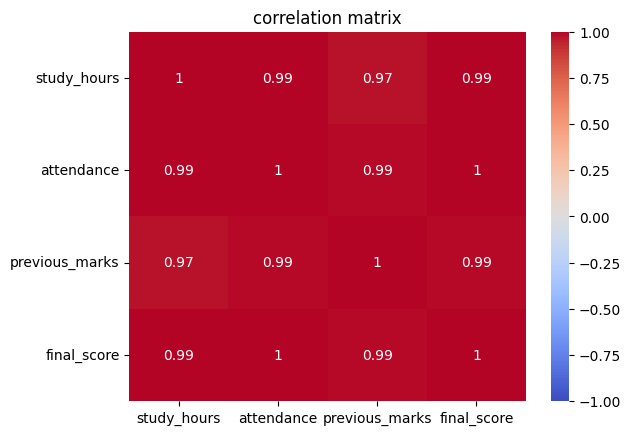

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Re-define data to ensure it's the DataFrame for correlation calculation
data = pd.DataFrame({
    "study_hours": [1,2,3,4,5,6],
    "attendance":[50,55,65,70,80,90],
    "previous_marks":[35,40,45,50,65,75],
    "final_score":[38,45,52,60,70,82]
})

correlation_matrix = data.corr(numeric_only=True)
print(correlation_matrix)

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("correlation matrix")
plt.show()

In [ ]:
#CHI-SQUARE TEST

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler

data = load_breast_cancer()
X = data.data
y = data.target

#chi-square requires non-negetive feture values
X_non_negetive = MinMaxScaler().fit_transform(X)

selector = SelectKBest(score_func=chi2, k=5)
X_selected = selector.fit_transform(X_non_negetive, y)

selected_features = data.feature_names[selector.get_support()]
print("Selected features:", selected_features)

Selected features: ['mean concavity' 'mean concave points' 'worst perimeter' 'worst area'
 'worst concave points']


In [ ]:
#UNIVARIATE FEATURE SELECTION

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.datasets import load_iris

iris = load_iris()
X,y = iris.data, iris.target
#X.shape
#X

X_select = SelectKBest(score_func=chi2, k=3).fit_transform(X,y)
#X_select.shape
X_select

array([[5.1, 1.4, 0.2],
       [4.9, 1.4, 0.2],
       [4.7, 1.3, 0.2],
       [4.6, 1.5, 0.2],
       [5. , 1.4, 0.2],
       [5.4, 1.7, 0.4],
       [4.6, 1.4, 0.3],
       [5. , 1.5, 0.2],
       [4.4, 1.4, 0.2],
       [4.9, 1.5, 0.1],
       [5.4, 1.5, 0.2],
       [4.8, 1.6, 0.2],
       [4.8, 1.4, 0.1],
       [4.3, 1.1, 0.1],
       [5.8, 1.2, 0.2],
       [5.7, 1.5, 0.4],
       [5.4, 1.3, 0.4],
       [5.1, 1.4, 0.3],
       [5.7, 1.7, 0.3],
       [5.1, 1.5, 0.3],
       [5.4, 1.7, 0.2],
       [5.1, 1.5, 0.4],
       [4.6, 1. , 0.2],
       [5.1, 1.7, 0.5],
       [4.8, 1.9, 0.2],
       [5. , 1.6, 0.2],
       [5. , 1.6, 0.4],
       [5.2, 1.5, 0.2],
       [5.2, 1.4, 0.2],
       [4.7, 1.6, 0.2],
       [4.8, 1.6, 0.2],
       [5.4, 1.5, 0.4],
       [5.2, 1.5, 0.1],
       [5.5, 1.4, 0.2],
       [4.9, 1.5, 0.2],
       [5. , 1.2, 0.2],
       [5.5, 1.3, 0.2],
       [4.9, 1.4, 0.1],
       [4.4, 1.3, 0.2],
       [5.1, 1.5, 0.2],
       [5. , 1.3, 0.3],
       [4.5, 1.3

In [ ]:
#ANOVA

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_iris

iris = load_iris()
X,y = iris.data, iris.target

selector = SelectKBest(score_func=f_classif, k=2)
X_selcted = selector.fit_transform(X,y)
selected_features = np.array(iris.feature_names)[selector.get_support()]
print("Selected features:", selected_features)


Selected features: ['petal length (cm)' 'petal width (cm)']
